# Homework 2

In [1]:
# %pip install pandas numpy seaborn matplotlib

In [2]:
import pandas as pd
import numpy as np

### Dataset

In [3]:
data = 'https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv'

In [4]:
!wget $data 

--2026-09-17 16:07:10--  https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.108.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 635180 (620K) [text/plain]
Saving to: ‘car_fuel_efficiency_2026.csv.4’

car_fuel_efficiency 100%[===================>] 620.29K  --.-KB/s    in 0.006s  

2026-09-17 16:07:10 (105 MB/s) - ‘car_fuel_efficiency_2026.csv.4’ saved [635180/635180]



In [5]:
df = pd.read_csv(data)

In [6]:
df.head()

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0


### Preparing the dataset 
Use only the following columns:

* `'engine_displacement'`,
* `'horsepower'`,
* `'vehicle_weight'`,
* `'model_year'`,
* `'fuel_efficiency_mpg'`

In [7]:
df = df[
    [
        'engine_displacement',
        'horsepower',
        'vehicle_weight',
        'model_year',
        'fuel_efficiency_mpg'
    ]
]

In [8]:
df.dtypes

engine_displacement      int64
horsepower             float64
vehicle_weight           int64
model_year               int64
fuel_efficiency_mpg    float64
dtype: object

### EDA

* Look at the `fuel_efficiency_mpg` variable. Does it have a long tail? 

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

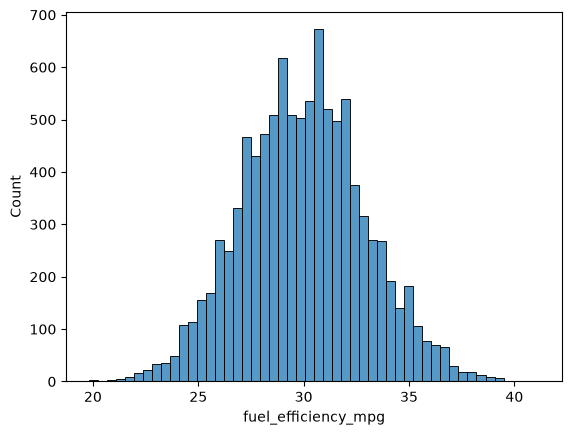

In [10]:
sns.histplot(df.fuel_efficiency_mpg, bins=50)   # No long tail

### Question 1

There's one column with missing values. What is it?

In [11]:
df.isnull().sum()

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

### Question 2

What's the median (50% percentile) for variable `'horsepower'`?

In [12]:
df.horsepower.median()

np.float64(254.0)

### Question 3

* We need to deal with missing values for the column from Q1.
* We have two options: fill it with 0 or with the mean of this variable.
* Try both options. For each, train a linear regression model without regularization using the code from the lessons.
* For computing the mean, use the training only!
* Use the validation dataset to evaluate the models and compare the RMSE of each option.
* Round the RMSE scores to 3 decimal digits using `round(score, 3)`. This
  keeps the imputation difference visible in this release.
* Which option gives better RMSE?


In [13]:
n = len(df)

n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

In [14]:
n_val, n_test, n_train

(2000, 2000, 6000)

In [15]:
n, n_val + n_test + n_train

(10000, 10000)

In [16]:
df.iloc[:10]

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2180,243.0,3870,2006,31.9
1,2390,272.0,4210,2008,31.3
2,2320,267.0,4240,1996,27.5
3,2130,258.0,4490,1989,28.5
4,2580,304.0,4510,1994,31.0
5,2290,266.0,4260,2007,31.2
6,2270,250.0,4310,1992,26.8
7,2370,279.0,4090,2005,30.2
8,2330,251.0,4230,1997,30.9
9,2330,280.0,4620,2004,31.2


In [17]:
idx = np.arange(n)
idx

array([   0,    1,    2, ..., 9997, 9998, 9999], shape=(10000,))

In [18]:
np.random.seed(42)
np.random.shuffle(idx)

In [19]:
idx

array([6252, 4684, 1731, ..., 5390,  860, 7270], shape=(10000,))

In [20]:
df.iloc[idx[:10]]

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
6252,1900,239.0,3790,2015,32.5
4684,2000,224.0,4380,1992,29.1
1731,2330,286.0,4090,2022,34.1
4742,2300,NaN,4150,1997,30.6
4521,2340,269.0,4400,2001,30.7
6340,2210,251.0,4540,2012,32.0
576,2280,259.0,4090,1995,27.4
5202,2640,297.0,4330,2014,30.0
6363,2400,272.0,4150,1998,30.4
439,2380,271.0,4530,2015,32.5


In [21]:
df_train = df.iloc[idx[:n_train]]
df_train

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
6252,1900,239.0,3790,2015,32.5
4684,2000,224.0,4380,1992,29.1
1731,2330,286.0,4090,2022,34.1
4742,2300,NaN,4150,1997,30.6
4521,2340,269.0,4400,2001,30.7
...,...,...,...,...,...
7895,2280,242.0,4590,2018,29.8
9590,2300,NaN,4240,1984,25.1
7288,2240,255.0,4190,1989,27.7
278,2430,254.0,4280,2020,31.6


In [22]:
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_val

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
2480,2240,265.0,3990,2004,30.4
289,2390,259.0,4770,2019,32.8
6086,2360,265.0,4320,2018,27.8
3075,2430,279.0,4430,2008,28.6
8123,2220,249.0,4030,1999,31.1
...,...,...,...,...,...
1638,1980,229.0,4140,2020,30.3
5891,2590,263.0,4630,1989,28.7
7427,2390,264.0,4550,2017,30.6
608,2330,244.0,4440,2014,31.0


In [23]:
df_test = df.iloc[idx[n_train + n_val:]]
df_test

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
399,2370,268.0,4410,1981,27.8
7247,2240,256.0,4220,2020,37.3
6406,2090,217.0,3910,2023,33.1
882,2280,251.0,4420,2021,31.3
3565,2450,256.0,4420,1979,26.4
...,...,...,...,...,...
5734,2100,257.0,4130,1988,30.7
5191,2160,231.0,4180,2000,25.5
5390,2430,246.0,4660,2013,30.1
860,2450,307.0,4500,2014,30.5


In [24]:
df_train.head()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
6252,1900,239.0,3790,2015,32.5
4684,2000,224.0,4380,1992,29.1
1731,2330,286.0,4090,2022,34.1
4742,2300,NaN,4150,1997,30.6
4521,2340,269.0,4400,2001,30.7


In [25]:
n_train, n_val, n_test

(6000, 2000, 2000)

In [26]:
len(df_train), len(df_val), len(df_test)

(6000, 2000, 2000)

In [27]:
df_train = df_train.reset_index(drop=True)
df_train

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,1900,239.0,3790,2015,32.5
1,2000,224.0,4380,1992,29.1
2,2330,286.0,4090,2022,34.1
3,2300,NaN,4150,1997,30.6
4,2340,269.0,4400,2001,30.7
...,...,...,...,...,...
5995,2280,242.0,4590,2018,29.8
5996,2300,NaN,4240,1984,25.1
5997,2240,255.0,4190,1989,27.7
5998,2430,254.0,4280,2020,31.6


In [28]:
df_val = df_val.reset_index(drop=True)
df_val

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2240,265.0,3990,2004,30.4
1,2390,259.0,4770,2019,32.8
2,2360,265.0,4320,2018,27.8
3,2430,279.0,4430,2008,28.6
4,2220,249.0,4030,1999,31.1
...,...,...,...,...,...
1995,1980,229.0,4140,2020,30.3
1996,2590,263.0,4630,1989,28.7
1997,2390,264.0,4550,2017,30.6
1998,2330,244.0,4440,2014,31.0


In [29]:
df_test = df_test.reset_index(drop=True)
df_test

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2370,268.0,4410,1981,27.8
1,2240,256.0,4220,2020,37.3
2,2090,217.0,3910,2023,33.1
3,2280,251.0,4420,2021,31.3
4,2450,256.0,4420,1979,26.4
...,...,...,...,...,...
1995,2100,257.0,4130,1988,30.7
1996,2160,231.0,4180,2000,25.5
1997,2430,246.0,4660,2013,30.1
1998,2450,307.0,4500,2014,30.5


Create y_train, y_val, y_test

In [30]:
df.columns

Index(['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year',
       'fuel_efficiency_mpg'],
      dtype='str')

In [31]:
y_train = df_train.fuel_efficiency_mpg.values
y_train

array([32.5, 29.1, 34.1, ..., 27.7, 31.6, 28. ], shape=(6000,))

In [32]:
y_val = df_val.fuel_efficiency_mpg.values
y_val

array([30.4, 32.8, 27.8, ..., 30.6, 31. , 30.8], shape=(2000,))

In [33]:
y_test = df_test.fuel_efficiency_mpg.values
y_test

array([27.8, 37.3, 33.1, ..., 30.1, 30.5, 34.9], shape=(2000,))

In [34]:
y_train.shape, y_val.shape, y_test.shape

((6000,), (2000,), (2000,))

Remove the target 'fuel_efficiency_mpg' from X

In [35]:
del df_train['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

In [36]:
df_train.columns

Index(['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year'], dtype='str')

In [37]:
X_train = df_train.values
X_val = df_val.values
X_test = df_test.values

In [38]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)     # w = (X^T.X)^-1.X^T.y
    
    return w_full[0], w_full[1:]

b = intercept  
w = coefficients/weightage

In [39]:
b, w = train_linear_regression(X_train, y_train)
b, w             # Output: (np.float64(nan), array([nan, nan, nan, nan]))

(np.float64(nan), array([nan, nan, nan, nan]))

In [40]:
y_pred = b + X_val.dot(w)

Fill the missing 'horsepower' with 0

Make copies so we don't destroy the original split:

In [41]:
df_train_0 = df_train.copy()
df_val_0 = df_val.copy()

In [42]:
df_train_0['horsepower'] = df_train_0['horsepower'].fillna(0)
df_val_0['horsepower'] = df_val_0['horsepower'].fillna(0)

Convert to NumPy:

In [43]:
X_train_0 = df_train_0.values
X_val_0 = df_val_0.values

In [44]:
df_train_0.isnull().sum()

engine_displacement    0
horsepower             0
vehicle_weight         0
model_year             0
dtype: int64

In [45]:
b, w = train_linear_regression(X_train_0, y_train)
b, w

(np.float64(-153.8849618823138),
 array([-1.51505520e-03, -4.74024794e-06, -3.95418397e-03,  1.02146785e-01]))

In [46]:
y_pred_0 = b + X_val_0.dot(w)
y_pred_0

array([31.64502134, 29.86572978, 31.58838899, ..., 30.53133298,
       30.75085098, 31.62912778], shape=(2000,))

In [47]:
def rmse(y, y_pred):
    se = (y - y_pred) ** 2
    mse = se.mean()
    
    return np.sqrt(mse)

In [48]:
score_0 = rmse(y_val, y_pred_0)
score_0.round(3)

np.float64(2.205)

Fill missing horsepower with the mean

In [49]:
mean = df_train['horsepower'].mean()
mean

np.float64(254.46338337605272)

In [50]:
df_train_mean = df_train.copy()
df_val_mean = df_val.copy()

In [51]:
df_train_mean['horsepower'] = df_train_mean['horsepower'].fillna(mean)
df_val_mean['horsepower'] = df_val_mean['horsepower'].fillna(mean)

In [52]:
X_train_mean = df_train_mean.values
X_val_mean = df_val_mean.values

In [53]:
b, w = train_linear_regression(X_train_mean, y_train)
b, w

(np.float64(-153.29645639114293),
 array([-0.00102386, -0.00648622, -0.00388828,  0.10197897]))

In [54]:
y_pred_mean = b + X_val_mean.dot(w)
y_pred_mean

array([31.54288381, 29.92505122, 31.56459523, ..., 30.54408311,
       30.85701236, 31.55313717], shape=(2000,))

In [55]:
score_mean = rmse(y_val, y_pred_mean)
score_mean.round(3)

np.float64(2.202)

In [56]:
print("RMSE with 0:", round(score_0, 3))
print("RMSE with mean:", round(score_mean, 3))

RMSE with 0: 2.205
RMSE with mean: 2.202


### Question 4

* Now let's train a regularized linear regression.
* For this question, fill the NAs with 0. 
* Try different values of `r` from this list: `[0, 0.01, 0.1, 1, 5, 10, 100]`.
* Use RMSE to evaluate the model on the validation dataset.
* Round the RMSE scores to 4 decimal digits. This keeps the small but real
  regularization differences visible instead of turning several choices into a tie.
* Which `r` gives the best RMSE?

If multiple options give the same best RMSE, select the smallest `r`.

In [57]:
def train_linear_regression_reg(X, y, r=0):    # r for regularization
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    
    return w_full[0], w_full[1:]

In [58]:
for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
    b, w = train_linear_regression_reg(X_train_0, y_train, r=r)

    y_pred = b + X_val_0.dot(w)
    score = rmse(y_val, y_pred)

    print(r, round(score, 4))

0 2.2053
0.01 2.2058
0.1 2.2241
1 2.3492
5 2.4094
10 2.4195
100 2.4292


### Question 5 

* We used seed 42 for splitting the data. Let's find out how selecting the seed influences our score.
* Try different seed values: `[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]`.
* For each seed, do the train/validation/test split with 60%/20%/20% distribution.
* Fill the missing values with 0 and train a model without regularization.
* For each seed, evaluate the model on the validation dataset and collect the RMSE scores. 
* What's the standard deviation of all the scores? To compute the standard deviation, use `np.std`.
* Round the result to 3 decimal digits (`round(std, 3)`)

What's the value of std?

In [59]:
scores = []

for seed in range(10):

    np.random.seed(seed)

    idx = np.arange(n)
    np.random.shuffle(idx)

    df_train = df.iloc[idx[:n_train]]
    df_val = df.iloc[idx[n_train:n_train + n_val]]

    y_train = df_train.fuel_efficiency_mpg.values
    y_val = df_val.fuel_efficiency_mpg.values

    X_train = df_train.drop(columns=['fuel_efficiency_mpg']).copy()
    X_val = df_val.drop(columns=['fuel_efficiency_mpg']).copy()

    X_train['horsepower'] = X_train['horsepower'].fillna(0)
    X_val['horsepower'] = X_val['horsepower'].fillna(0)

    b, w = train_linear_regression(X_train.values, y_train)

    y_pred = b + X_val.values.dot(w)

    score = rmse(y_val, y_pred)

    scores.append(score)

In [60]:
print(pd.DataFrame(scores))

          0
0  2.239204
1  2.202113
2  2.163420
3  2.204359
4  2.201880
5  2.245785
6  2.269721
7  2.190795
8  2.216611
9  2.207037


In [61]:
std = np.std(scores)
print(round(std, 3))

0.029


### Question 6

* Split the dataset like previously, use seed 9.
* Combine train and validation datasets.
* Fill the missing values with 0 and train a model with `r=0.001`. 
* What's the RMSE on the test dataset?

In [62]:
np.random.seed(9)

idx = np.arange(n)
np.random.shuffle(idx)

In [63]:
df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]

In [64]:
df_test.columns

Index(['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year'], dtype='str')

In [65]:
df_full_train = pd.concat([df_train, df_val])
df_full_train

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
3644,2320,246.0,4100,2014,32.5
9184,2230,252.0,4250,1998,33.2
520,2700,276.0,4490,2008,32.4
5685,2220,269.0,4060,2004,29.9
2401,2370,NaN,4690,1979,26.4
...,...,...,...,...,...
8981,2690,324.0,4510,2023,35.7
3978,1920,190.0,4000,1998,30.8
6198,1800,225.0,3980,1994,29.1
1102,1970,232.0,3560,2009,32.2


In [66]:
y_full_train = np.concatenate([y_train, y_val])
y_full_train

array([32.5, 33.2, 32.4, ..., 29.1, 32.2, 35.6], shape=(8000,))

In [67]:
X_full_train = df_full_train.drop(columns=['fuel_efficiency_mpg']).copy()
X_test = df_test.copy()

In [68]:
X_full_train['horsepower'] = X_full_train['horsepower'].fillna(0)
X_test['horsepower'] = X_test['horsepower'].fillna(0)

In [69]:
b, w = train_linear_regression_reg(
    X_full_train.values,
    y_full_train,
    r=0.001
)

In [70]:
y_pred = b + X_test.values.dot(w)

In [71]:
score = rmse(y_test, y_pred)

print(round(score, 4))

2.2383
